# CASO DE USO: MegaStore - Marketplace Inteligente tipo Amazon

SISTEMAS IMPLEMENTADOS:
1. Item-Based Collaborative Filtering → "Productos relacionados"
2. Content-Based Filtering → Recomendaciones por descripción
3. Hybrid System → Combinando ambos enfoques

DATASET: Amazon Electronics Reviews & Metadata
- 194,439 reviews de productos electrónicos
- Metadata rica: títulos, descripciones, categorías
- Comportamiento real de usuarios

OBJETIVO: Construir un sistema de recomendación completo que funcione como el de Amazon en producción

# Notas 
- Si quiero recomendar un producto y quiero saber que es similar a otro --> Similaridad coseno
- Los modelos LLMs
- Hay mas niveles? Si, depende de tus nivels matematicos
- Un Level 4 o Level 5 --> Imagenes. Recomendar imagenes. Como Pinterest? Como recomendar imagenes?
- Una imagen se puede dividir en N capas. Descomponer por colores, etc.
- Check the Pintereste Engineering [URL](https://medium.com/pinterest-engineering/how-pinterest-leverages-realtime-user-actions-in-recommendation-to-boost-homefeed-engagement-volume-165ae2e8cde8)
- Nivel 5. Grafos. Relaciones entre personas de crimenes. 

## Dependencias

In [3]:
#!pip install tensorflow==2.17.1
!pip install langchain-openai
!pip install textblob

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 624.3/624.3 kB 23.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 41.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [textblob]1/3 [nltk]


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity, linear_kernel
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
import gzip
import json
import re
import urllib.request
import os
from collections import defaultdict, Counter
from textblob import TextBlob
from openai import OpenAI
from getpass import getpass

# IA Generativa

In [5]:
# OPENAI_API_KEY
print("Insertar el API Key de OpenAI")
openai_key = getpass()

Insertar el API Key de OpenAI


In [6]:
from langchain_openai import OpenAIEmbeddings
embeddings_model = OpenAIEmbeddings(
    model="text-embedding-3-small",#text-embedding-3-small", #"text-embedding-3-large",
    openai_api_key=openai_key
)

docs = [
        "Texto de prueba",
        "texto 2",
        "La capital de Francia es Paris"
    ]
embeddings = embeddings_model.embed_documents(docs)

print(f"Cantidad de embeddings: {len(embeddings)}")
print(f"Tamaño de cada embedding: {len(embeddings[0])}")

/Users/sebastianchavarry01/Documents/dmc/ai_engineer_diploma/venv_py39/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Cantidad de embeddings: 3
Tamaño de cada embedding: 1536


In [7]:
print(embeddings[0])

[-0.0032601691782474518, 0.022556845098733902, 0.0015252608573064208, -0.020454294979572296, -0.019640011712908745, 0.004220293369144201, -0.0040926821529865265, 0.010397296398878098, 0.02478093095123768, -0.01222031656652689, 0.050752904266119, 0.004581859335303307, 0.019712932407855988, 0.017245778813958168, 0.02414895035326481, 0.04158918559551239, -0.03480754792690277, -0.02351696975529194, -0.03014061227440834, 0.05240577459335327, -0.009783545508980751, -0.012354005128145218, 0.041151657700538635, -0.017877759411931038, 0.031890712678432465, -0.04766592010855675, -0.019822314381599426, -0.0015510870143771172, 0.041783638298511505, -0.04766592010855675, 0.025497986003756523, -0.05551706254482269, 0.031501803547143936, -0.026543185114860535, 0.01078013051301241, 0.019919542595744133, 0.021086275577545166, 0.015106766484677792, 0.015349836088716984, -0.04292606562376022, 0.001259403652511537, -0.015775207430124283, 0.019822314381599426, 0.041491955518722534, 0.020259838551282883, 0.

In [8]:
# Configuración visual
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)

# Notas

- Los embeddings son mejores porque capturan semantica

# Generative AI Embeddings vs TF-IDF Embeddings

In [7]:
# Dataset de textos con similitudes léxicas pero diferentes significados
texts = [
    # Grupo 1: "banco" - institución financiera vs asiento
    "Fui al banco a depositar mi dinero en la cuenta de ahorros",
    "Tengo mis ahorros en el banco, siempre voy a depositarlo",
    "Me senté en el banco del parque a descansar un momento",
    "El banco central subió las tasas de interés este mes",
    "Construí un banco de madera para el jardín",

    # Grupo 2: "gato" - animal vs herramienta
    "Mi gato negro duerme en el sofá toda la tarde",
    "Necesito un gato hidráulico para cambiar la llanta del carro",
    "El gato de mi vecina es muy cariñoso y juguetón",
    "El mecánico usó el gato para levantar el vehículo",

    # Grupo 3: "capital" - ciudad vs dinero
    "París es la capital de Francia y una ciudad hermosa",
    "Necesito más capital para invertir en mi negocio",
    "La capital del país tiene muchos monumentos históricos",
    "El capital inicial fue suficiente para empezar la empresa",

    # Grupo 4: "red" - internet vs color/malla
    "La red de internet está muy lenta hoy en casa",
    "Compré una red de pescar para ir al lago",
    "Mi computadora no se conecta a la red wifi",
    "Los pescadores lanzaron la red al mar temprano",

    # Grupo 5: "planta" - vegetal vs fábrica/piso
    "Esta planta verde necesita más agua y luz solar",
    "La planta industrial produce miles de productos diarios",
    "Mi oficina está en la planta baja del edificio",
    "Regalé una planta de flores a mi madre"
]

print(f"Total de textos: {len(texts)}")
print("\nPrimeros 5 textos:")
for i, text in enumerate(texts[:5]):
    print(f"{i+1}: {text}")

Total de textos: 21

Primeros 5 textos:
1: Fui al banco a depositar mi dinero en la cuenta de ahorros
2: Tengo mis ahorros en el banco, siempre voy a depositarlo
3: Me senté en el banco del parque a descansar un momento
4: El banco central subió las tasas de interés este mes
5: Construí un banco de madera para el jardín


## TF-IDF

In [8]:
print("IMPLEMENTANDO TF-IDF")
print("="*50)

# Crear y entrenar el vectorizador TF-IDF
tfidf_vectorizer = TfidfVectorizer(
    max_features=1000,
    min_df=1,
    max_df=0.8,
    stop_words='english',
    ngram_range=(1, 2)  # incluir bigramas
)

# Obtener la matriz TF-IDF
tfidf_matrix = tfidf_vectorizer.fit_transform(texts)
print(f"Forma de la matriz TF-IDF: {tfidf_matrix.shape}")

# Ver algunas características más importantes
feature_names = tfidf_vectorizer.get_feature_names_out()
print(f"Número total de características: {len(feature_names)}")
print(f"Primeras 10 características: {feature_names[:10]}")

IMPLEMENTANDO TF-IDF
Forma de la matriz TF-IDF: (21, 250)
Número total de características: 250
Primeras 10 características: ['agua' 'agua luz' 'ahorros' 'ahorros en' 'al' 'al banco' 'al lago'
 'al mar' 'baja' 'baja del']


## IA Generativa

In [9]:
# Obtener embeddings
print("Obteniendo embeddings...")
embeddings = embeddings_model.embed_documents(texts)
embeddings_array = np.array(embeddings)

print(f"Forma de la matriz de embeddings: {embeddings_array.shape}")
print(f"Dimensiones de cada embedding: {embeddings_array.shape[1]}")

Obteniendo embeddings...
Forma de la matriz de embeddings: (21, 1536)
Dimensiones de cada embedding: 1536


## Funcion de similitud

In [10]:
def cosine_similarity_simple(vec1, vec2):
    """
    Calcula la similitud coseno entre dos vectores
    """
    # Calcular el producto punto
    dot_product = np.dot(vec1, vec2)

    # Calcular las normas
    norm_vec1 = np.linalg.norm(vec1)
    norm_vec2 = np.linalg.norm(vec2)

    # Calcular similitud coseno
    similarity = dot_product / (norm_vec1 * norm_vec2)

    return similarity

## Matrices de similitud

In [11]:
print("CALCULANDO SIMILITUDES")

# Matriz de similitud TF-IDF
tfidf_similarities = cosine_similarity(tfidf_matrix)
print("Matriz de similitud TF-IDF calculada")

# Matriz de similitud para embeddings
embeddings_similarities = cosine_similarity(embeddings_array)
print("Matriz de similitud Embeddings calculada")

CALCULANDO SIMILITUDES
Matriz de similitud TF-IDF calculada
Matriz de similitud Embeddings calculada


In [12]:
def analizar_similitudes(texto_idx1, texto_idx2, nombre_par):
    print(f"\n{nombre_par}:")
    print(f"Texto 1: {texts[texto_idx1]}")
    print(f"Texto 2: {texts[texto_idx2]}")

    # TF-IDF
    tfidf_sim = tfidf_similarities[texto_idx1, texto_idx2]

    # Embeddings
    embedding_sim = embeddings_similarities[texto_idx1, texto_idx2]

    print(f"Similitud TF-IDF: {tfidf_sim:.4f}")
    print(f"Similitud Embeddings: {embedding_sim:.4f}")
    print(f"Diferencia: {abs(tfidf_sim - embedding_sim):.4f}")

In [13]:
# Mismo significado, palabras diferentes
analizar_similitudes(0, 1, "BANCO financiero (similares en significado)")


BANCO financiero (similares en significado):
Texto 1: Fui al banco a depositar mi dinero en la cuenta de ahorros
Texto 2: Tengo mis ahorros en el banco, siempre voy a depositarlo
Similitud TF-IDF: 0.1067
Similitud Embeddings: 0.7160
Diferencia: 0.6093


In [14]:
# Mismas palabras, diferente significado
analizar_similitudes(0, 1, "BANCO - financiero vs asiento (misma palabra, diferente significado)")


BANCO - financiero vs asiento (misma palabra, diferente significado):
Texto 1: Fui al banco a depositar mi dinero en la cuenta de ahorros
Texto 2: Tengo mis ahorros en el banco, siempre voy a depositarlo
Similitud TF-IDF: 0.1067
Similitud Embeddings: 0.7160
Diferencia: 0.6093


In [15]:
# Gato animal vs herramienta
analizar_similitudes(4, 5, "GATO - animal vs herramienta (misma palabra, diferente significado)")


GATO - animal vs herramienta (misma palabra, diferente significado):
Texto 1: Construí un banco de madera para el jardín
Texto 2: Mi gato negro duerme en el sofá toda la tarde
Similitud TF-IDF: 0.0261
Similitud Embeddings: 0.2814
Diferencia: 0.2553


In [16]:
# Capital ciudad vs dinero
analizar_similitudes(8, 9, "CAPITAL - ciudad vs dinero (misma palabra, diferente significado)")


CAPITAL - ciudad vs dinero (misma palabra, diferente significado):
Texto 1: El mecánico usó el gato para levantar el vehículo
Texto 2: París es la capital de Francia y una ciudad hermosa
Similitud TF-IDF: 0.0000
Similitud Embeddings: 0.0457
Diferencia: 0.0457


In [17]:
# Textos completamente diferentes
analizar_similitudes(2, 4, "Textos completamente diferentes (banco vs gato)")


Textos completamente diferentes (banco vs gato):
Texto 1: Me senté en el banco del parque a descansar un momento
Texto 2: Construí un banco de madera para el jardín
Similitud TF-IDF: 0.0735
Similitud Embeddings: 0.5369
Diferencia: 0.4633


GENERANDO VISUALIZACIONES


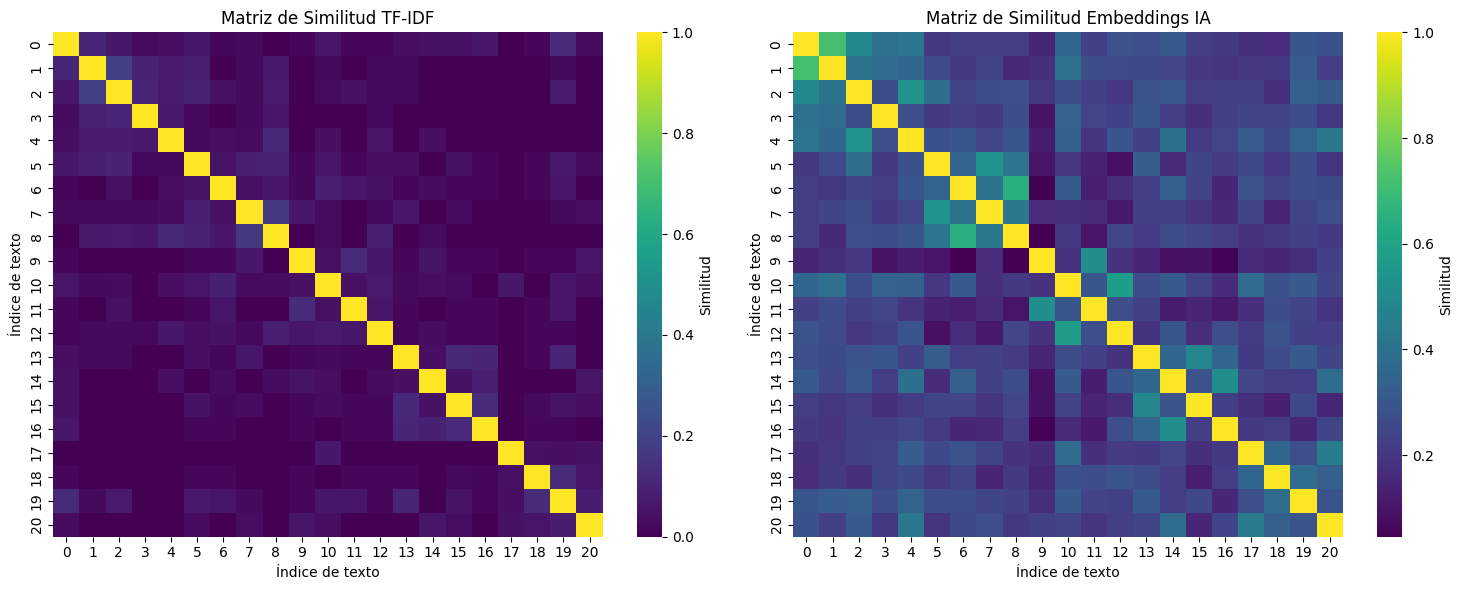

In [18]:
print("GENERANDO VISUALIZACIONES")

# Crear visualización de las matrices de similitud
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# TF-IDF heatmap
sns.heatmap(tfidf_similarities,
            annot=False,
            cmap='viridis',
            ax=axes[0],
            cbar_kws={'label': 'Similitud'})
axes[0].set_title('Matriz de Similitud TF-IDF')
axes[0].set_xlabel('Índice de texto')
axes[0].set_ylabel('Índice de texto')

# Embeddings heatmap
sns.heatmap(embeddings_similarities,
            annot=False,
            cmap='viridis',
            ax=axes[1],
            cbar_kws={'label': 'Similitud'})
axes[1].set_title('Matriz de Similitud Embeddings IA')
axes[1].set_xlabel('Índice de texto')
axes[1].set_ylabel('Índice de texto')

plt.tight_layout()
plt.show()

In [19]:
# Obtener solo el triángulo superior (sin diagonal) para evitar autocomparaciones
triu_indices = np.triu_indices_from(tfidf_similarities, k=1)
tfidf_upper = tfidf_similarities[triu_indices]
embeddings_upper = embeddings_similarities[triu_indices]

print(f"Estadísticas TF-IDF:")
print(f"  Media: {np.mean(tfidf_upper):.4f}")
print(f"  Mediana: {np.median(tfidf_upper):.4f}")
print(f"  Std: {np.std(tfidf_upper):.4f}")
print(f"  Min: {np.min(tfidf_upper):.4f}")
print(f"  Max: {np.max(tfidf_upper):.4f}")

print(f"\nEstadísticas Embeddings:")
print(f"  Media: {np.mean(embeddings_upper):.4f}")
print(f"  Mediana: {np.median(embeddings_upper):.4f}")
print(f"  Std: {np.std(embeddings_upper):.4f}")
print(f"  Min: {np.min(embeddings_upper):.4f}")
print(f"  Max: {np.max(embeddings_upper):.4f}")

Estadísticas TF-IDF:
  Media: 0.0302
  Mediana: 0.0201
  Std: 0.0339
  Min: 0.0000
  Max: 0.1837

Estadísticas Embeddings:
  Media: 0.2529
  Mediana: 0.2369
  Std: 0.1012
  Min: 0.0457
  Max: 0.7160


## Descarga del dataset Amazon Electronics

In [20]:
# URLs para dataset pequeño (5-core) - usuarios e items con al menos 5 reviews
REVIEWS_URL = "http://snap.stanford.edu/data/amazon/productGraph/categoryFiles/reviews_Electronics_5.json.gz"
METADATA_URL = "http://snap.stanford.edu/data/amazon/productGraph/categoryFiles/meta_Electronics.json.gz"

REVIEWS_FILE = "amazon_electronics_reviews.json.gz"
METADATA_FILE = "amazon_electronics_meta.json.gz"

def download_if_not_exists(url, filename):
    """Descargar archivo si no existe"""
    if not os.path.exists(filename):
        print(f" Descargando {filename}...")
        try:
            urllib.request.urlretrieve(url, filename)
            print(f" {filename} descargado exitosamente")
        except Exception as e:
            print(f" Error descargando {filename}: {e}")
            return False
    else:
        print(f" {filename} ya existe")
    return True

In [21]:
# Descargar archivos
download_if_not_exists(REVIEWS_URL, REVIEWS_FILE)
download_if_not_exists(METADATA_URL, METADATA_FILE)

 Descargando amazon_electronics_reviews.json.gz...
 amazon_electronics_reviews.json.gz descargado exitosamente
 Descargando amazon_electronics_meta.json.gz...
 amazon_electronics_meta.json.gz descargado exitosamente


True

## Procesamiento de datos

In [22]:
def parse_amazon_data(filepath, max_lines=10000):
    """Parsear datos de Amazon (JSON por línea comprimido)"""
    import ast

    data = []
    lines_processed = 0
    json_errors = 0
    ast_errors = 0
    empty_lines = 0

    try:
        print(f"🔍 Procesando {filepath}...")
        with gzip.open(filepath, 'rt', encoding='utf-8') as f:
            for i, line in enumerate(f):
                lines_processed += 1

                if i >= max_lines:
                    print(f"   Límite de {max_lines:,} líneas alcanzado")
                    break

                line = line.strip()
                if not line:
                    empty_lines += 1
                    continue

                # Mostrar primera línea para debug
                if i == 0:
                    print(f"    Primera línea: {line[:100]}...")
                    # Detectar formato
                    if line.startswith('{') and '"' in line:
                        print("    Formato detectado: JSON estándar")
                    elif line.startswith('{') and "'" in line:
                        print("    Formato detectado: Python dict (comillas simples)")

                parsed_data = None

                # Intentar primero con JSON estándar
                try:
                    parsed_data = json.loads(line)
                except json.JSONDecodeError:
                    json_errors += 1
                    # Si falla JSON, intentar con ast.literal_eval (para formato Python dict)
                    try:
                        parsed_data = ast.literal_eval(line)
                    except (ValueError, SyntaxError) as e:
                        ast_errors += 1
                        if (json_errors + ast_errors) <= 3:  # Mostrar solo los primeros errores
                            print(f"    Error en línea {i+1}: No se pudo parsear como JSON ni como dict")
                        continue

                if parsed_data is not None:
                    data.append(parsed_data)

        print(f" {len(data):,} registros cargados desde {filepath}")
        print(f"    Estadísticas: {lines_processed:,} líneas procesadas, {empty_lines:,} vacías")
        print(f"    Errores: {json_errors:,} JSON, {ast_errors:,} parsing")

    except Exception as e:
        print(f" Error abriendo {filepath}: {e}")
        return []

    return data

def clean_text(text):
    """Limpiar texto para TF-IDF"""
    if pd.isna(text) or text == '':
        return ''

    # Convertir a string y minúsculas
    text = str(text).lower()

    # Remover HTML tags
    text = re.sub(r'<[^>]+>', '', text)

    # Remover caracteres especiales pero mantener espacios
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)

    # Remover espacios múltiples
    text = re.sub(r'\s+', ' ', text).strip()

    return text

## Carga y exploración de los datos

In [23]:
# Cargar reviews (limitado para el taller)
print(" Cargando reviews...")
reviews_data = parse_amazon_data(REVIEWS_FILE, max_lines=8000)
reviews_df = pd.DataFrame(reviews_data)

# Cargar metadata
print(" Cargando metadata...")
metadata_data = parse_amazon_data(METADATA_FILE, max_lines=1000)
metadata_df = pd.DataFrame(metadata_data)

# Información básica
print(f"\n INFORMACIÓN DEL DATASET:")
print(f"    Reviews cargadas: {len(reviews_df):,}")
print(f"    Productos con metadata: {len(metadata_df):,}")

if not reviews_df.empty:
    print(f"    Usuarios únicos: {reviews_df['reviewerID'].nunique():,}")
    print(f"    Productos únicos en reviews: {reviews_df['asin'].nunique():,}")
    if 'overall' in reviews_df.columns:
        print(f"   ⭐ Rating promedio: {reviews_df['overall'].mean():.2f}")

# Explorar estructura de datos
print(f"\n ESTRUCTURA DE DATOS:")
print(" Columnas en reviews:")
print(f"   {list(reviews_df.columns)}")
print("\n Columnas en metadata:")
print(f"   {list(metadata_df.columns)}")

 Cargando reviews...
🔍 Procesando amazon_electronics_reviews.json.gz...
    Primera línea: {"reviewerID": "AO94DHGC771SJ", "asin": "0528881469", "reviewerName": "amazdnu", "helpful": [0, 0], ...
    Formato detectado: JSON estándar
   Límite de 8,000 líneas alcanzado
 8,000 registros cargados desde amazon_electronics_reviews.json.gz
    Estadísticas: 8,001 líneas procesadas, 0 vacías
    Errores: 0 JSON, 0 parsing
 Cargando metadata...
🔍 Procesando amazon_electronics_meta.json.gz...
    Primera línea: {'asin': '0132793040', 'imUrl': 'http://ecx.images-amazon.com/images/I/31JIPhp%2BGIL.jpg', 'descript...
    Formato detectado: Python dict (comillas simples)
   Límite de 1,000 líneas alcanzado
 1,000 registros cargados desde amazon_electronics_meta.json.gz
    Estadísticas: 1,001 líneas procesadas, 0 vacías
    Errores: 1,000 JSON, 0 parsing

 INFORMACIÓN DEL DATASET:
    Reviews cargadas: 8,000
    Productos con metadata: 1,000
    Usuarios únicos: 7,052
    Productos únicos en reviews:

In [24]:
reviews_df.head()

,reviewerID,asin,reviewerName,helpful,reviewText,overall,summary,unixReviewTime,reviewTime
0,AO94DHGC771SJ,0528881469,amazdnu,"[0, 0]",We got this GPS for my husband who is an (OTR)...,5.0,Gotta have GPS!,1370131200,"06 2, 2013"
1,AMO214LNFCEI4,0528881469,Amazon Customer,"[12, 15]","I'm a professional OTR truck driver, and I bou...",1.0,Very Disappointed,1290643200,"11 25, 2010"
2,A3N7T0DY83Y4IG,0528881469,C. A. Freeman,"[43, 45]","Well, what can I say. I've had this unit in m...",3.0,1st impression,1283990400,"09 9, 2010"
3,A1H8PY3QHMQQA0,0528881469,"Dave M. Shaw ""mack dave""","[9, 10]","Not going to write a long review, even thought...",2.0,"Great grafics, POOR GPS",1290556800,"11 24, 2010"
4,A24EV6RXELQZ63,0528881469,Wayne Smith,"[0, 0]",I've had mine for a year and here's what we go...,1.0,"Major issues, only excuses for support",1317254400,"09 29, 2011"


In [25]:
metadata_df.head()

,asin,imUrl,description,categories,title,price,salesRank,related,brand
0,0132793040,http://ecx.images-amazon.com/images/I/31JIPhp%...,The Kelby Training DVD Mastering Blend Modes i...,"[[Electronics, Computers & Accessories, Cables...",Kelby Training DVD: Mastering Blend Modes in A...,NaN,NaN,NaN,NaN
1,0321732944,http://ecx.images-amazon.com/images/I/31uogm6Y...,NaN,"[[Electronics, Computers & Accessories, Cables...",Kelby Training DVD: Adobe Photoshop CS5 Crash ...,NaN,NaN,NaN,NaN
2,0439886341,http://ecx.images-amazon.com/images/I/51k0qa8f...,Digital Organizer and Messenger,"[[Electronics, Computers & Accessories, PDAs, ...",Digital Organizer and Messenger,8.15,{'Electronics': 144944},"{'also_viewed': ['0545016266', 'B009ECM8QY', '...",NaN
3,0511189877,http://ecx.images-amazon.com/images/I/41HaAhbv...,The CLIKR-5 UR5U-8780L remote control is desig...,"[[Electronics, Accessories & Supplies, Audio &...",CLIKR-5 Time Warner Cable Remote Control UR5U-...,23.36,NaN,"{'also_viewed': ['B001KC08A4', 'B00KUL8O0W', '...",NaN
4,0528881469,http://ecx.images-amazon.com/images/I/51FnRkJq...,"Like its award-winning predecessor, the Intell...","[[Electronics, GPS & Navigation, Vehicle GPS, ...",Rand McNally 528881469 7-inch Intelliroute TND...,299.99,NaN,"{'also_viewed': ['B006ZOI9OY', 'B00C7FKT2A', '...",NaN


In [26]:
print(f"Tamaño de reviews: {len(reviews_df)}")
conteo_nan_reviews = reviews_df.isnull().sum()
print(conteo_nan_reviews)

print(f"\nTamaño de metadata: {len(metadata_df)}")
conteo_nan_metadata = metadata_df.isnull().sum()
print(conteo_nan_metadata)

Tamaño de reviews: 8000
reviewerID         0
asin               0
reviewerName      32
helpful            0
reviewText         0
overall            0
summary            0
unixReviewTime     0
reviewTime         0
dtype: int64

Tamaño de metadata: 1000
asin             0
imUrl            0
description     76
categories       0
title            8
price          346
salesRank      665
related        487
brand          791
dtype: int64


## Preparación y limpieza de datos

In [27]:
# Limpieza de datos de metadata
metadata_clean = metadata_df[['asin', 'description', 'categories', 'title']].copy()
metadata_clean.columns = ['item_id', 'description', 'categories', 'title']
metadata_clean = metadata_clean.dropna()

print(f"Después de limpieza: {len(metadata_clean)} filas")

Después de limpieza: 918 filas


In [28]:
# Limpieza de datos de reviews
reviews_clean = reviews_df[['reviewerID', 'asin', 'overall']].copy()
reviews_clean.columns = ['user_id', 'item_id', 'rating']
reviews_clean = reviews_clean.dropna()

print(f"Después de limpieza: {len(reviews_clean)} filas")

Después de limpieza: 8000 filas


In [29]:
print(f" Datos limpios:")
print(f"    Reviews: {len(reviews_clean):,}")
print(f"    Productos: {len(metadata_clean):,}")

# Análisis de intersección
print(f"\n ANÁLISIS DE INTERSECCIÓN DE DATOS:")
print(f"    IDs únicos en reviews: {reviews_clean['item_id'].nunique():,}")
print(f"    IDs únicos en metadata: {metadata_clean['item_id'].nunique():,}")

 Datos limpios:
    Reviews: 8,000
    Productos: 918

 ANÁLISIS DE INTERSECCIÓN DE DATOS:
    IDs únicos en reviews: 318
    IDs únicos en metadata: 918


In [30]:
# Verificar intersección
common_items = set(reviews_clean['item_id']) & set(metadata_clean['item_id'])
print(f"IDs comunes: {len(common_items):,}")

if len(common_items) == 0:
    print(" NO HAY INTERSECCIÓN - Creando dataset sintético para el tutorial...")
else:
    # Usar datos reales si hay intersección
    reviews_final = reviews_clean[reviews_clean['item_id'].isin(common_items)]
    metadata_final = metadata_clean[metadata_clean['item_id'].isin(common_items)]
    print(f" Usando datos reales:")

print(f"    Reviews finales: {len(reviews_final):,}")
print(f"    Productos finales: {len(metadata_final):,}")
print(f"    Usuarios únicos: {reviews_final['user_id'].nunique():,}")

IDs comunes: 42
 Usando datos reales:
    Reviews finales: 1,045
    Productos finales: 42
    Usuarios únicos: 1,007


## Análisis exploratorio

In [31]:
if len(reviews_final) > 0:
    print(" ESTADÍSTICAS GENERALES:")
    print(f"    Rating promedio: {reviews_final['rating'].mean():.2f}")
    print(f"    Mediana de rating: {reviews_final['rating'].median():.1f}")

    # Verificar que hay datos para mode
    mode_values = reviews_final['rating'].mode()
    if len(mode_values) > 0:
        print(f"    Rating más común: {mode_values.iloc[0]}")
    else:
        print(f"    Rating más común: N/A")

    # Análisis de actividad
    user_activity = reviews_final.groupby('user_id').size()
    item_popularity = reviews_final.groupby('item_id').size()

    print(f"\n ANÁLISIS DE USUARIOS:")
    print(f"    Promedio reviews por usuario: {user_activity.mean():.1f}")
    print(f"    Máximo reviews por usuario: {user_activity.max()}")
    print(f"    Mínimo reviews por usuario: {user_activity.min()}")

    print(f"\n ANÁLISIS DE PRODUCTOS:")
    print(f"    Promedio reviews por producto: {item_popularity.mean():.1f}")
    print(f"    Producto más popular: {item_popularity.max()} reviews")
else:
    print(" No hay datos de reviews para analizar")
    # Crear datos mínimos para que el resto del código funcione
    user_activity = pd.Series([1], index=['U0001'])
    item_popularity = pd.Series([1], index=['B000001X'])

 ESTADÍSTICAS GENERALES:
    Rating promedio: 4.13
    Mediana de rating: 5.0
    Rating más común: 5.0

 ANÁLISIS DE USUARIOS:
    Promedio reviews por usuario: 1.0
    Máximo reviews por usuario: 5
    Mínimo reviews por usuario: 1

 ANÁLISIS DE PRODUCTOS:
    Promedio reviews por producto: 24.9
    Producto más popular: 219 reviews


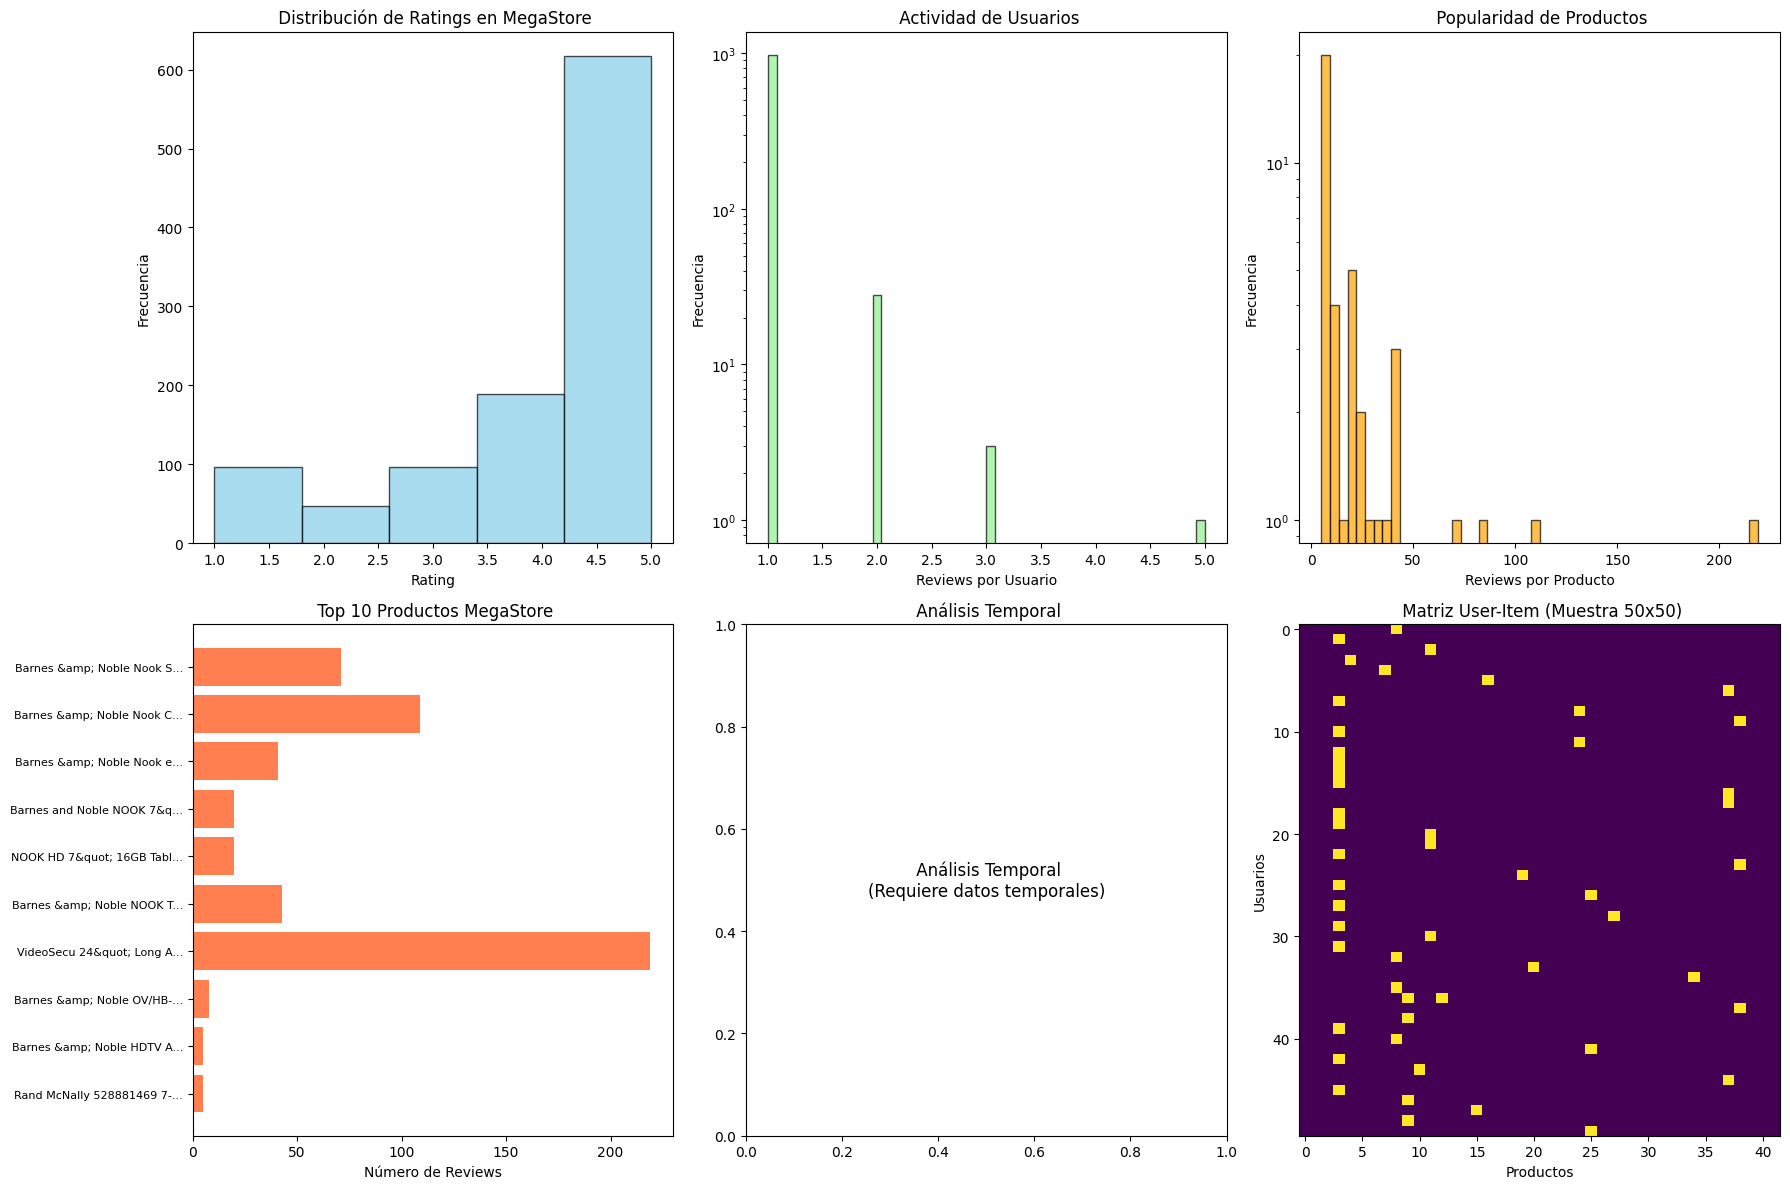

In [32]:
# Visualizaciones
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Distribución de ratings
axes[0,0].hist(reviews_final['rating'], bins=5, edgecolor='black', alpha=0.7, color='skyblue')
axes[0,0].set_title(' Distribución de Ratings en MegaStore')
axes[0,0].set_xlabel('Rating')
axes[0,0].set_ylabel('Frecuencia')

# Actividad de usuarios
axes[0,1].hist(user_activity, bins=50, edgecolor='black', alpha=0.7, color='lightgreen')
axes[0,1].set_title(' Actividad de Usuarios')
axes[0,1].set_xlabel('Reviews por Usuario')
axes[0,1].set_ylabel('Frecuencia')
axes[0,1].set_yscale('log')

# Popularidad de productos
axes[0,2].hist(item_popularity, bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[0,2].set_title(' Popularidad de Productos')
axes[0,2].set_xlabel('Reviews por Producto')
axes[0,2].set_ylabel('Frecuencia')
axes[0,2].set_yscale('log')

# Top 10 productos más populares
top_items = item_popularity.head(10)
product_names = []
for item_id in top_items.index:
    title = metadata_final[metadata_final['item_id'] == item_id]['title']
    if not title.empty:
        name = title.iloc[0][:25] + '...' if len(title.iloc[0]) > 25 else title.iloc[0]
    else:
        name = f"Producto {item_id[:8]}"
    product_names.append(name)

axes[1,0].barh(range(len(product_names)), top_items.values, color='coral')
axes[1,0].set_yticks(range(len(product_names)))
axes[1,0].set_yticklabels(product_names, fontsize=8)
axes[1,0].set_title(' Top 10 Productos MegaStore')
axes[1,0].set_xlabel('Número de Reviews')

# Distribución temporal (si hay timestamp)
axes[1,1].text(0.5, 0.5, ' Análisis Temporal\n(Requiere datos temporales)',
               ha='center', va='center', transform=axes[1,1].transAxes, fontsize=12)
axes[1,1].set_title(' Análisis Temporal')

# Matriz de sparsity (muestra)
sample_matrix = reviews_final.pivot_table(
    index='user_id', columns='item_id', values='rating', fill_value=0
).iloc[:50, :50]
axes[1,2].imshow(sample_matrix > 0, cmap='viridis', aspect='auto')
axes[1,2].set_title(' Matriz User-Item (Muestra 50x50)')
axes[1,2].set_xlabel('Productos')
axes[1,2].set_ylabel('Usuarios')

plt.tight_layout()
plt.show()

In [33]:
# Calcular sparsity (con validación)
if len(reviews_final) > 0:
    total_users = reviews_final['user_id'].nunique()
    total_items = reviews_final['item_id'].nunique()
    total_ratings = len(reviews_final)
    possible_ratings = total_users * total_items
    sparsity = (1 - total_ratings / possible_ratings) * 100 if possible_ratings > 0 else 0

    print(f"\n ANÁLISIS DE SPARSITY:")
    print(f"    Total posibles ratings: {possible_ratings:,}")
    print(f"    Ratings existentes: {total_ratings:,}")
    print(f"    Sparsity: {sparsity:.2f}%")
else:
    sparsity = 99.0  # Valor por defecto
    print(f"\n Sin datos suficientes para calcular sparsity")


 ANÁLISIS DE SPARSITY:
    Total posibles ratings: 42,294
    Ratings existentes: 1,045
    Sparsity: 97.53%


In [34]:
reviews_final.info()
reviews_final.describe(include="all")

<class 'pandas.core.frame.DataFrame'>
Index: 1045 entries, 0 to 1056
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   user_id  1045 non-null   object 
 1   item_id  1045 non-null   object 
 2   rating   1045 non-null   float64
dtypes: float64(1), object(2)
memory usage: 32.7+ KB


,user_id,item_id,rating
count,1045,1045,1045.000000
unique,1007,42,NaN
top,A3LDPF5FMB782Z,0972683275,NaN
freq,5,219,NaN
mean,NaN,NaN,4.133014
std,NaN,NaN,1.293408
min,NaN,NaN,1.000000
25%,NaN,NaN,4.000000
50%,NaN,NaN,5.000000
75%,NaN,NaN,5.000000


In [35]:
metadata_final.info()
metadata_final.describe(include="all")

<class 'pandas.core.frame.DataFrame'>
Index: 42 entries, 4 to 894
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   item_id      42 non-null     object
 1   description  42 non-null     object
 2   categories   42 non-null     object
 3   title        42 non-null     object
dtypes: object(4)
memory usage: 1.6+ KB


,item_id,description,categories,title
count,42,42,42,42
unique,42,42,25,42
top,0528881469,"Like its award-winning predecessor, the Intell...","[[Electronics, eBook Readers & Accessories, eB...",Rand McNally 528881469 7-inch Intelliroute TND...
freq,1,1,5,1


## ITEM-BASED COLLABORATIVE FILTERING

## Clase que implementa el modelo

In [36]:
class ItemBasedCollaborativeFiltering:
    def __init__(self, ratings_df, min_interactions=5):
        """
        Item-based collaborative filtering implementation

        Parameters:
        - ratings_df: DataFrame with columns ['user_id', 'item_id', 'rating']
        - min_interactions: Minimum interactions required for items to be considered
        """
        self.ratings_df = ratings_df
        self.min_interactions = min_interactions
        self.item_similarity_matrix = None
        self.user_item_matrix = None
        self.item_means = None

    def build_model(self):
        """Build the item-item similarity matrix"""
        print("Building item-based collaborative filtering model...")

        # Filter items with minimum interactions
        item_counts = self.ratings_df['item_id'].value_counts()
        valid_items = item_counts[item_counts >= self.min_interactions].index
        filtered_df = self.ratings_df[self.ratings_df['item_id'].isin(valid_items)]

        print(f"Items after filtering (min {self.min_interactions} interactions): {len(valid_items)}")

        # Create user-item matrix
        self.user_item_matrix = filtered_df.pivot_table(
            index='user_id',
            columns='item_id',
            values='rating',
            fill_value=0
        )

        # Calculate item means (for mean-centered similarity)
        self.item_means = self.user_item_matrix.mean(axis=0)

        # Mean-center the matrix
        user_item_centered = self.user_item_matrix.subtract(self.item_means, axis=1)

        # Calculate item-item cosine similarity
        print("Calculating item-item similarities...")
        self.item_similarity_matrix = cosine_similarity(user_item_centered.T)

        # Convert to DataFrame for easier handling
        items = self.user_item_matrix.columns
        self.item_similarity_df = pd.DataFrame(
            self.item_similarity_matrix,
            index=items,
            columns=items
        )

        print("Item-based model built successfully!")

    def get_item_similarities(self, item_id, top_k=10):
        """Get most similar items to a given item"""
        if self.item_similarity_df is None:
            raise ValueError("Model not built yet. Call build_model() first.")

        if item_id not in self.item_similarity_df.index:
            return f"Item {item_id} not found in similarity matrix"

        similarities = self.item_similarity_df[item_id].drop(item_id).sort_values(ascending=False)
        return similarities.head(top_k)

    def predict_rating(self, user_id, item_id, k=20):
        """Predict rating for a user-item pair using k most similar items"""
        if self.item_similarity_df is None:
            raise ValueError("Model not built yet. Call build_model() first.")

        # Check if user and item exist in our matrices
        if user_id not in self.user_item_matrix.index:
            return self.item_means.get(item_id, self.ratings_df['rating'].mean())

        if item_id not in self.item_similarity_df.columns:
            return self.ratings_df['rating'].mean()

        # Get user's ratings
        user_ratings = self.user_item_matrix.loc[user_id]

        # Get items that user has rated
        rated_items = user_ratings[user_ratings > 0].index

        if len(rated_items) == 0:
            return self.item_means.get(item_id, self.ratings_df['rating'].mean())

        # Get similarities between target item and user's rated items
        item_similarities = self.item_similarity_df.loc[item_id, rated_items]

        # Sort by similarity and take top k
        item_similarities = item_similarities.sort_values(ascending=False).head(k)

        # Calculate weighted prediction
        numerator = 0
        denominator = 0

        for similar_item, similarity in item_similarities.items():
            if similarity > 0:  # Only consider positive similarities
                user_rating = user_ratings[similar_item]
                item_mean = self.item_means[similar_item]
                numerator += similarity * (user_rating - item_mean)
                denominator += abs(similarity)

        if denominator == 0:
            return self.item_means.get(item_id, self.ratings_df['rating'].mean())

        predicted_rating = self.item_means[item_id] + (numerator / denominator)

        # Clip to valid rating range
        predicted_rating = max(1, min(5, predicted_rating))

        return predicted_rating

    def recommend_items(self, user_id, n_recommendations=10, exclude_rated=True):
        """Generate item recommendations for a user"""
        if self.item_similarity_df is None:
            raise ValueError("Model not built yet. Call build_model() first.")

        if user_id not in self.user_item_matrix.index:
            # For new users, recommend popular items
            popular_items = self.ratings_df.groupby('item_id').agg({
                'rating': ['count', 'mean']
            }).round(2)
            popular_items.columns = ['count', 'mean_rating']
            popular_items = popular_items.sort_values(['count', 'mean_rating'], ascending=False)
            return popular_items.head(n_recommendations)

        # Get items user has already rated
        user_ratings = self.user_item_matrix.loc[user_id]
        rated_items = set(user_ratings[user_ratings > 0].index) if exclude_rated else set()

        # Get all items in similarity matrix
        all_items = set(self.item_similarity_df.columns)
        candidate_items = all_items - rated_items if exclude_rated else all_items

        # Predict ratings for candidate items
        recommendations = []
        for item_id in candidate_items:
            predicted_rating = self.predict_rating(user_id, item_id)
            recommendations.append({
                'item_id': item_id,
                'predicted_rating': predicted_rating
            })

        # Sort by predicted rating
        recommendations = sorted(recommendations, key=lambda x: x['predicted_rating'], reverse=True)

        return recommendations[:n_recommendations]

## Construir el modelo

In [37]:
# Initialize and build the item-based model
print("ITEM-BASED COLLABORATIVE FILTERING")
print("="*40)

item_cf = ItemBasedCollaborativeFiltering(reviews_final, min_interactions=10)
item_cf.build_model()

ITEM-BASED COLLABORATIVE FILTERING
Building item-based collaborative filtering model...
Items after filtering (min 10 interactions): 22
Calculating item-item similarities...
Item-based model built successfully!


## Estadísticas

In [38]:
# Demonstrate the model with examples
print(f"\nMODEL STATISTICS")
print("-"*20)
print(f"User-item matrix shape: {item_cf.user_item_matrix.shape}")
print(f"Item similarity matrix shape: {item_cf.item_similarity_matrix.shape}")


MODEL STATISTICS
--------------------
User-item matrix shape: (883, 22)
Item similarity matrix shape: (22, 22)


## Ejemplo de similitud de items

In [ ]:
# Example: Find similar items with detailed information
sample_item = item_cf.user_item_matrix.columns[3]
sample_item_info = metadata_final[metadata_final['item_id'] == sample_item].iloc[0]
similar_items = item_cf.get_item_similarities(sample_item, 5)

print(f"\nSIMILAR ITEMS ANALYSIS:")
print("="*50)
print(f"BASE ITEM: {sample_item}")
print(f"Title: {sample_item_info['title']}")
print(f"Categories: {sample_item_info['categories']}")
print(f"Description: {str(sample_item_info['description'])[:150]}...")

print(f"\nMOST SIMILAR ITEMS:")
print("-"*30)
for item_id, similarity in similar_items.items():
    try:
        item_info = metadata_final[metadata_final['item_id'] == item_id].iloc[0]
        print(f"\nSimilarity: {similarity:.3f}")
        print(f"  Item ID: {item_id}")
        print(f"  Title: {item_info['title']}")
        print(f"  Categories: {item_info['categories']}")
        print(f"  Description: {str(item_info['description'])[:100]}...")
    except:
        print(f"  {item_id}: {similarity:.3f} (metadata not found)")


SIMILAR ITEMS ANALYSIS:
BASE ITEM: 1400501520
Title: NOOK HD 7&quot; 16GB Tablet
Categories: [['Electronics', 'Computers & Accessories', 'Tablets']]
Description: For design, mobility, and performance; choose the NOOK HD Tablet. This tablet lets you read books, watch movies or stream online content. It features ...

MOST SIMILAR ITEMS:
------------------------------

Similarity: 0.126
  Item ID: 1400698987
  Title: Nook HD 7&quot; 8GB Tablet
  Categories: [['Electronics', 'Computers & Accessories', 'Tablets']]
  Description: The Nook HD Tablet has an amazing combination of style and functionality. With this tablet you can t...

Similarity: 0.061
  Item ID: 1400501466
  Title: Barnes &amp; Noble NOOK Tablet 16gb (Color, BNTV250)
  Categories: [['Electronics', 'Computers & Accessories', 'Tablets']]
  Description: Enjoy your digital books, magazines and newspapers in color, plus movies, TV shows and music from th...

Similarity: 0.044
  Item ID: 1400501776
  Title: Barnes and Noble NOOK 7

# Notas
- Que significa los negativos? Son opuestos. 

## Ejecución de recomendación para usuarios

In [40]:
# Example: Get recommendations for a user with complete profile
sample_user = item_cf.user_item_matrix.index[10]  # Choose user with more data
user_history = reviews_final[reviews_final['user_id'] == sample_user].sort_values('rating', ascending=False)
recommendations = item_cf.recommend_items(sample_user, 5)

print(f"\n\nUSER PROFILE ANALYSIS:")
print("="*50)
print(f"USER ID: {sample_user}")
print(f"Total ratings: {len(user_history)}")
print(f"Average rating: {user_history['rating'].mean():.2f}")
print(f"Rating distribution: {dict(user_history['rating'].value_counts().sort_index())}")

print(f"\nUSER'S TOP RATED ITEMS:")
print("-"*30)
for i, (_, rating_row) in enumerate(user_history.head(5).iterrows(), 1):
    try:
        item_info = metadata_final[metadata_final['item_id'] == rating_row['item_id']].iloc[0]
        print(f"{i}. Rating: {rating_row['rating']}/5")
        print(f"   Title: {item_info['title']}")
        print(f"   Categories: {item_info['categories']}")
    except:
        print(f"{i}. Item {rating_row['item_id']}: {rating_row['rating']}/5 (metadata not found)")

print(f"\nITEM-BASED CF RECOMMENDATIONS FOR USER {sample_user}:")
print("="*60)
for i, rec in enumerate(recommendations, 1):
    try:
        item_info = metadata_final[metadata_final['item_id'] == rec['item_id']].iloc[0]
        avg_rating = reviews_final[reviews_final['item_id'] == rec['item_id']]['rating'].mean()
        total_reviews = len(reviews_final[reviews_final['item_id'] == rec['item_id']])

        print(f"\n{i}. PREDICTED RATING: {rec['predicted_rating']:.2f}/5")
        print(f"   Item ID: {rec['item_id']}")
        print(f"   Title: {item_info['title']}")
        print(f"   Categories: {item_info['categories']}")
        print(f"   Description: {str(item_info['description'])[:150]}...")
        print(f"   Actual avg rating: {avg_rating:.2f}/5 ({total_reviews} reviews)")
    except:
        print(f"\n{i}. Item: {rec['item_id']} - Predicted Rating: {rec['predicted_rating']:.2f} (metadata not found)")

print("\nItem-based collaborative filtering model completed!")



USER PROFILE ANALYSIS:
USER ID: A11EKN3A8FUEDC
Total ratings: 1
Average rating: 5.00
Rating distribution: {5.0: 1}

USER'S TOP RATED ITEMS:
------------------------------
1. Rating: 5.0/5
   Title: VideoSecu 24&quot; Long Arm TV Wall Mount Low Profile Full Motion Cantilever Swing &amp; Tilt wall bracket for most 22&quot; to 55&quot; LED LCD TV Monitor Flat Panel Screen VESA 200x200 400x400 up to 600x400mm - Articulating Arm Extend up to 24&quot; MAH
   Categories: [['Electronics', 'Accessories & Supplies', 'Audio & Video Accessories', 'TV Accessories & Parts', 'TV Ceiling & Wall Mounts']]

ITEM-BASED CF RECOMMENDATIONS FOR USER A11EKN3A8FUEDC:

1. PREDICTED RATING: 0.47/5
   Item ID: 1400532655
   Title: Barnes &amp; Noble Nook Color eReader
   Categories: [['Electronics', 'eBook Readers & Accessories', 'eBook Readers']]
   Description: Barnes & Noble Nook Color eReaderStunning 7-inch color touchscreen; Magazines & newspapers in rich color; Kids'books come alive; Over 2 million title

# Content-Based Filtering

## Clase que implementa el modelo

In [41]:
from scipy.sparse import csr_matrix

class ContentBasedFiltering:
    def __init__(self, metadata_df, ratings_df):
        """
        Content-based filtering using TF-IDF on item features

        Parameters:
        - metadata_df: DataFrame with item metadata
        - ratings_df: DataFrame with ratings for building user profiles
        """
        self.metadata_df = metadata_df.copy()
        self.ratings_df = ratings_df
        self.tfidf_vectorizer = None
        self.content_matrix = None
        self.item_similarity_matrix = None

        self.embeddings_model = OpenAIEmbeddings(
            model="text-embedding-3-small",#text-embedding-3-small", #"text-embedding-3-large",
            openai_api_key=openai_key
        )

    def preprocess_content(self):
        """Preprocess and combine content features"""
        print("Preprocessing content features...")

        def convert_to_string(value):
            """Convert value to string, handling lists, arrays and None values"""
            # Handle numpy arrays and pandas arrays first
            if hasattr(value, '__array__') or isinstance(value, (list, tuple)):
                try:
                    # Convert to list if it's an array
                    if hasattr(value, 'tolist'):
                        value_list = value.tolist()
                    else:
                        value_list = list(value)
                    return ', '.join([str(item) for item in value_list if item is not None])
                except:
                    return str(value)

            # Handle scalar values
            try:
                if pd.isna(value) or value is None:
                    return ''
                else:
                    return str(value)
            except (ValueError, TypeError):
                # If pd.isna() fails, just convert to string
                return str(value) if value is not None else ''

        # Convert all columns to strings, handling lists
        self.metadata_df['title'] = self.metadata_df['title'].apply(convert_to_string)
        self.metadata_df['description'] = self.metadata_df['description'].apply(convert_to_string)
        self.metadata_df['categories'] = self.metadata_df['categories'].apply(convert_to_string)

        # Combine all text features
        # Give different weights to different features
        self.metadata_df['combined_features'] = (
            self.metadata_df['title'] + ' ' +  # Title is most important
            self.metadata_df['categories'] + ' ' +  # Categories are moderately important
            self.metadata_df['description']  # Description provides context
        )

        # Clean the text
        self.metadata_df['combined_features'] = (
            self.metadata_df['combined_features']
            .str.lower()
            .str.replace(r'[^\w\s]', ' ', regex=True)
            .str.replace(r'\s+', ' ', regex=True)
            .str.strip()
        )

        print(f"Combined features created for {len(self.metadata_df)} items")

    def build_model(self, max_features=5000, min_df=2, max_df=0.8):
        """Build TF-IDF matrix and calculate item similarities"""
        if 'combined_features' not in self.metadata_df.columns:
            self.preprocess_content()



        # Initialize TF-IDF vectorizer
        '''
        self.tfidf_vectorizer = TfidfVectorizer(
            max_features=max_features,
            min_df=min_df,
            max_df=max_df,
            stop_words='english',
            ngram_range=(1, 2)  # Include bigrams
        )

        # Fit and transform the combined features
        self.content_matrix0 = self.tfidf_vectorizer.fit_transform(
            self.metadata_df['combined_features']
        )
        '''

        embeddings = embeddings_model.embed_documents(self.metadata_df['combined_features'])

        self.content_matrix = csr_matrix(embeddings)
        print(f"Embedding matrix shape: {self.content_matrix.shape}")
        #print(f"Vocabulary size: {len(self.tfidf_vectorizer.vocabulary_)}")

        # Calculate item-item cosine similarity
        print("Calculating content-based similarities...")
        self.item_similarity_matrix = linear_kernel(self.content_matrix, self.content_matrix)

        # Create mapping from item_id to matrix index
        self.item_to_idx = {item_id: idx for idx, item_id in enumerate(self.metadata_df['item_id'])}
        self.idx_to_item = {idx: item_id for item_id, idx in self.item_to_idx.items()}

        print("Content-based model built successfully!")

    def build_model1(self, max_features=5000, min_df=2, max_df=0.8):
        """Build TF-IDF matrix and calculate item similarities"""
        if 'combined_features' not in self.metadata_df.columns:
            self.preprocess_content()

        print("Building TF-IDF matrix...")

        # Initialize TF-IDF vectorizer
        self.tfidf_vectorizer = TfidfVectorizer(
            max_features=max_features,
            min_df=min_df,
            max_df=max_df,
            stop_words='english',
            ngram_range=(1, 2)  # Include bigrams
        )

        # Fit and transform the combined features
        self.content_matrix = self.tfidf_vectorizer.fit_transform(
            self.metadata_df['combined_features']
        )
        print(f"AUA: {type(self.content_matrix)}")

        print(f"TF-IDF matrix shape: {self.content_matrix.shape}")
        print(f"Vocabulary size: {len(self.tfidf_vectorizer.vocabulary_)}")

        # Calculate item-item cosine similarity
        print("Calculating content-based similarities...")
        self.item_similarity_matrix = linear_kernel(self.content_matrix, self.content_matrix)

        # Create mapping from item_id to matrix index
        self.item_to_idx = {item_id: idx for idx, item_id in enumerate(self.metadata_df['item_id'])}
        self.idx_to_item = {idx: item_id for item_id, idx in self.item_to_idx.items()}

        print("Content-based model built successfully!")

    def get_content_similarities(self, item_id, top_k=10):
        """Get items most similar to a given item based on content"""
        if self.item_similarity_matrix is None:
            raise ValueError("Model not built yet. Call build_model() first.")

        if item_id not in self.item_to_idx:
            return f"Item {item_id} not found in metadata"

        idx = self.item_to_idx[item_id]
        similarities = self.item_similarity_matrix[idx]

        # Get top similar items (excluding the item itself)
        similar_indices = similarities.argsort()[::-1][1:top_k+1]

        results = []
        for similar_idx in similar_indices:
            similar_item_id = self.idx_to_item[similar_idx]
            similarity_score = similarities[similar_idx]
            results.append({
                'item_id': similar_item_id,
                'similarity': similarity_score
            })

        return results

    def build_user_profile(self, user_id, min_rating=3.0):
        """Build user profile based on highly rated items"""
        user_ratings = self.ratings_df[
            (self.ratings_df['user_id'] == user_id) &
            (self.ratings_df['rating'] >= min_rating)
        ]

        if len(user_ratings) == 0:
            return None

        # Get content vectors for user's liked items
        liked_items = user_ratings['item_id'].tolist()
        liked_indices = [self.item_to_idx[item] for item in liked_items if item in self.item_to_idx]

        if len(liked_indices) == 0:
            return None

        # Weight by rating and create weighted average profile
        profile_vector = np.zeros(self.content_matrix.shape[1])
        total_weight = 0

        for item_id, rating in zip(user_ratings['item_id'], user_ratings['rating']):
            if item_id in self.item_to_idx:
                idx = self.item_to_idx[item_id]
                weight = rating
                profile_vector += weight * self.content_matrix[idx].toarray().flatten()
                total_weight += weight

        if total_weight > 0:
            profile_vector /= total_weight

        return profile_vector

    def recommend_items(self, user_id, n_recommendations=10, exclude_rated=True):
        """Generate content-based recommendations for a user"""
        if self.item_similarity_matrix is None:
            raise ValueError("Model not built yet. Call build_model() first.")

        # Build user profile
        user_profile = self.build_user_profile(user_id)

        if user_profile is None:
            # Fallback: recommend popular items
            popular_items = (
                self.ratings_df.groupby('item_id')
                .agg({'rating': ['count', 'mean']})
                .round(2)
            )
            popular_items.columns = ['count', 'mean_rating']
            popular_items = popular_items.sort_values(['mean_rating', 'count'], ascending=False)
            return popular_items.head(n_recommendations).reset_index()

        # Calculate similarities between user profile and all items
        profile_similarities = linear_kernel([user_profile], self.content_matrix).flatten()

        # Get items user has rated (for exclusion)
        rated_items = set(self.ratings_df[self.ratings_df['user_id'] == user_id]['item_id']) if exclude_rated else set()

        # Create recommendations
        recommendations = []
        for idx, similarity in enumerate(profile_similarities):
            item_id = self.idx_to_item[idx]
            if exclude_rated and item_id in rated_items:
                continue

            recommendations.append({
                'item_id': item_id,
                'similarity_score': similarity,
                'title': self.metadata_df[self.metadata_df['item_id'] == item_id]['title'].iloc[0]
            })

        # Sort by similarity and return top N
        recommendations = sorted(recommendations, key=lambda x: x['similarity_score'], reverse=True)

        return recommendations[:n_recommendations]

    def get_feature_importance(self, item_id, top_k=10):
        """Get most important TF-IDF features for an item"""
        if self.tfidf_vectorizer is None:
            raise ValueError("Model not built yet. Call build_model() first.")

        if item_id not in self.item_to_idx:
            return f"Item {item_id} not found"

        idx = self.item_to_idx[item_id]
        feature_scores = self.content_matrix[idx].toarray().flatten()

        # Get feature names
        feature_names = self.tfidf_vectorizer.get_feature_names_out()

        # Get top features
        top_indices = feature_scores.argsort()[::-1][:top_k]

        results = []
        for feature_idx in top_indices:
            if feature_scores[feature_idx] > 0:
                results.append({
                    'feature': feature_names[feature_idx],
                    'score': feature_scores[feature_idx]
                })

        return results

## Construir el modelo

In [42]:
# Initialize and build the content-based model
print("CONTENT-BASED FILTERING")
print("="*30)

content_cf = ContentBasedFiltering(metadata_final, reviews_final)
content_cf.build_model(max_features=3000)

CONTENT-BASED FILTERING
Preprocessing content features...
Combined features created for 42 items
Embedding matrix shape: (42, 1536)
Calculating content-based similarities...
Content-based model built successfully!


## Estadísticas

In [43]:
print(f"\nMODEL STATISTICS")
print("-"*20)
print(f"Items in content matrix: {content_cf.content_matrix.shape[0]}")
print(f"Embedding features: {content_cf.content_matrix.shape[1]}")


MODEL STATISTICS
--------------------
Items in content matrix: 42
Embedding features: 1536


## Ejemplo

In [44]:
# Example: Find similar items based on content with detailed information
sample_item = metadata_final['item_id'].iloc[5]  # Choose a different item for variety
sample_item_info = metadata_final[metadata_final['item_id'] == sample_item].iloc[0]
similar_items = content_cf.get_content_similarities(sample_item, 5)

print(f"\nCONTENT-BASED SIMILARITY ANALYSIS:")
print("="*50)
print(f"BASE ITEM: {sample_item}")
print(f"Title: {sample_item_info['title']}")
print(f"Categories: {sample_item_info['categories']}")
print(f"Description: {str(sample_item_info['description'])[:200]}...")

print(f"\nMOST CONTENT-SIMILAR ITEMS:")
print("-"*40)
for item in similar_items:
    try:
        item_info = metadata_final[metadata_final['item_id'] == item['item_id']].iloc[0]
        avg_rating = reviews_final[reviews_final['item_id'] == item['item_id']]['rating'].mean()
        total_reviews = len(reviews_final[reviews_final['item_id'] == item['item_id']])

        print(f"\nContent Similarity: {item['similarity']:.3f}")
        print(f"  Title: {item_info['title']}")
        print(f"  Categories: {item_info['categories']}")
        print(f"  Description: {str(item_info['description'])[:120]}...")
        print(f"  Average rating: {avg_rating:.2f}/5 ({total_reviews} reviews)")
    except:
        print(f"  Item {item['item_id']}: {item['similarity']:.3f} (metadata not found)")


CONTENT-BASED SIMILARITY ANALYSIS:
BASE ITEM: 140053271X
Title: Barnes &amp; Noble Nook Simple Touch eBook Reader (Wi-Fi Only)
Categories: [['Electronics', 'eBook Readers & Accessories', 'eBook Readers']]
Description: Barnes & Noble Nook Simple Touch Wi-Fi ReaderIncredibly easy-just touch and read; Ultra-light, thin and the longest battery life; Most advanced E Ink 6" display w/ crisp fonts; Expert recommendations ...

MOST CONTENT-SIMILAR ITEMS:
----------------------------------------

Content Similarity: 0.860
  Title: Barnes &amp; Noble Nook eReader - no 3G
  Categories: [['Electronics', 'eBook Readers & Accessories']]
  Description: Barnes & Noble Nook eReader - no 3GMeet nook. Access to over one million eBooks, newspapers, and magazines downloaded wi...
  Average rating: 3.61/5 (41 reviews)

Content Similarity: 0.829
  Title: Barnes &amp; Noble Nook Color eReader
  Categories: [['Electronics', 'eBook Readers & Accessories', 'eBook Readers']]
  Description: Barnes & Noble Nook Co

## Ejemplo

In [45]:
# Example: Get recommendations for a user with complete profile
sample_user = reviews_final['user_id'].iloc[25]  # Choose user with reasonable history
user_history = reviews_final[reviews_final['user_id'] == sample_user].sort_values('rating', ascending=False)
content_recommendations = content_cf.recommend_items(sample_user, 5)

print(f"\n\nUSER PROFILE FOR CONTENT-BASED RECOMMENDATIONS:")
print("="*60)
print(f"USER ID: {sample_user}")
print(f"Total ratings: {len(user_history)}")
print(f"Average rating: {user_history['rating'].mean():.2f}")

# Analyze user's category preferences
user_categories = []
high_rated_items = user_history[user_history['rating'] >= 4]
for _, rating_row in high_rated_items.iterrows():
    item_cats = metadata_final[metadata_final['item_id'] == rating_row['item_id']]['categories']
    if not item_cats.empty:
        try:
            # Try to check if value is not NA, handle arrays
            cat_value = item_cats.iloc[0]
            if hasattr(cat_value, '__array__') or isinstance(cat_value, (list, tuple)):
                is_valid = len(cat_value) > 0 if hasattr(cat_value, '__len__') else True
            else:
                is_valid = pd.notna(cat_value) and cat_value != ''
            if is_valid:
                cats = str(item_cats.iloc[0]).split(',')
                user_categories.extend([cat.strip() for cat in cats])
        except:
            pass  # Skip this item if there's an issue processing categories

from collections import Counter
if user_categories:
    top_categories = Counter(user_categories).most_common(3)
    print(f"Preferred categories: {', '.join([f'{cat} ({count})' for cat, count in top_categories])}")

print(f"\nUSER'S HIGHLY RATED ITEMS (4+ stars):")
print("-"*40)
for i, (_, rating_row) in enumerate(high_rated_items.head(5).iterrows(), 1):
    try:
        item_info = metadata_final[metadata_final['item_id'] == rating_row['item_id']].iloc[0]
        print(f"{i}. Rating: {rating_row['rating']}/5")
        print(f"   Title: {item_info['title']}")
        print(f"   Categories: {item_info['categories']}")
    except:
        print(f"{i}. Item {rating_row['item_id']}: {rating_row['rating']}/5")

print(f"\nCONTENT-BASED RECOMMENDATIONS FOR USER {sample_user}:")
print("="*65)
for i, rec in enumerate(content_recommendations, 1):
    try:
        # Get detailed item information
        item_info = metadata_final[metadata_final['item_id'] == rec['item_id']].iloc[0]
        avg_rating = reviews_final[reviews_final['item_id'] == rec['item_id']]['rating'].mean()
        total_reviews = len(reviews_final[reviews_final['item_id'] == rec['item_id']])

        print(f"\n{i}. SIMILARITY SCORE: {rec['similarity_score']:.3f}")
        print(f"   Item ID: {rec['item_id']}")
        print(f"   Title: {rec['title']}")
        print(f"   Categories: {item_info['categories']}")
        print(f"   Description: {str(item_info['description'])[:150]}...")
        print(f"   Community rating: {avg_rating:.2f}/5 ({total_reviews} reviews)")

        # Show why this item was recommended (top content features)
        important_features = content_cf.get_feature_importance(rec['item_id'], 3)
        if important_features:
            print(f"   Key features: {', '.join([f['feature'] for f in important_features])}")

    except Exception as e:
        print(f"\n{i}. {rec['title'][:50]}... - Score: {rec['similarity_score']:.3f}")



USER PROFILE FOR CONTENT-BASED RECOMMENDATIONS:
USER ID: A7060R14RJF3I
Total ratings: 1
Average rating: 4.00
Preferred categories: [['Electronics' (1), 'Accessories & Supplies' (1), 'Audio & Video Accessories' (1)

USER'S HIGHLY RATED ITEMS (4+ stars):
----------------------------------------
1. Rating: 4.0/5
   Title: VideoSecu 24&quot; Long Arm TV Wall Mount Low Profile Full Motion Cantilever Swing &amp; Tilt wall bracket for most 22&quot; to 55&quot; LED LCD TV Monitor Flat Panel Screen VESA 200x200 400x400 up to 600x400mm - Articulating Arm Extend up to 24&quot; MAH
   Categories: [['Electronics', 'Accessories & Supplies', 'Audio & Video Accessories', 'TV Accessories & Parts', 'TV Ceiling & Wall Mounts']]

CONTENT-BASED RECOMMENDATIONS FOR USER A7060R14RJF3I:

1. SIMILARITY SCORE: 0.430
   Item ID: 8918010656
   Title: Perfect Pixel 30&quot; Yamakasi 301 Sparta 2560x1600 S-IPS DVI-D WQHD Computer Monitor
   Categories: [['Electronics', 'Computers & Accessories', 'Monitors']]
   D